# NeuroDyads Pre-Task Analysis Notebook

## Data Setup and Assumptions


In [ ]:
!pip install mne cebra scikit-learn scipy matplotlib pandas

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne.preprocessing import ICA

from scipy.signal import welch
from scipy.stats import kurtosis

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import cebra

RNG = np.random.default_rng(42)
np.random.seed(42)

In [ ]:
DATA_DIR = Path('/content')
EDF_A = DATA_DIR / 'Listener.edf'
EDF_B = DATA_DIR / 'Speaker.edf'

assert EDF_A.exists(), f'Missing file: {EDF_A}'
assert EDF_B.exists(), f'Missing file: {EDF_B}'
print('Using files:')
print('A ->', EDF_A)
print('B ->', EDF_B)

Using files:
A -> /content/Listener.edf
B -> /content/Speaker.edf


## Part 1: EEG Preprocessing
### Step 1: Load EDF files and verify DIN1 event markers

In [ ]:
def read_raw(path):
    return mne.io.read_raw_edf(path, preload=True, verbose=False)

def get_din1_onsets_sec(raw):
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    inv = {v: k for k, v in event_id.items()}
    sfreq = raw.info['sfreq']

    onsets = []
    for sample, _, code in events:
        label = inv.get(code, '')
        if 'DIN1' in label.upper():
            onsets.append(sample / sfreq)

    onsets = sorted(onsets)
    if len(onsets) < 3:
        raise RuntimeError(
            f'Expected at least 3 DIN1 markers, found {len(onsets)}. '
            'Inspect annotations manually.'
        )
    return onsets

raw_A = read_raw(EDF_A)
raw_B = read_raw(EDF_B)

onsets_A = get_din1_onsets_sec(raw_A)
onsets_B = get_din1_onsets_sec(raw_B)

print('A DIN1 onsets (s):', onsets_A[:5])
print('B DIN1 onsets (s):', onsets_B[:5])
print('A channels:', len(raw_A.ch_names), '| B channels:', len(raw_B.ch_names))

A DIN1 onsets (s): [np.float64(1.004), np.float64(148.776), np.float64(149.052)]
B DIN1 onsets (s): [np.float64(0.788), np.float64(148.56), np.float64(148.836)]
A channels: 65 | B channels: 65


In [ ]:
# Build shared segmentation windows to keep participants time-locked.
# Positive: DIN1(1) -> DIN1(2), Negative: DIN1(3) -> end.

pos_start = max(onsets_A[0], onsets_B[0])
pos_end = min(onsets_A[1], onsets_B[1])

neg_start = max(onsets_A[2], onsets_B[2])
neg_end = min(raw_A.times[-1], raw_B.times[-1])

if not (pos_end > pos_start and neg_end > neg_start):
    raise RuntimeError('Invalid shared crop windows. Check marker extraction and recording lengths.')

print(f'Positive window: {pos_start:.2f}s -> {pos_end:.2f}s')
print(f'Negative window: {neg_start:.2f}s -> {neg_end:.2f}s')

Positive window: 1.00s -> 148.56s
Negative window: 149.05s -> 303.00s


In [ ]:
def drop_vref_channel(raw):
    # Prefer explicit names first; fallback to dropping channel index 65 if present.
    candidate_names = [name for name in raw.ch_names if 'VREF' in name.upper() or name.upper() in {'E65', '65'}]
    if candidate_names:
        raw = raw.copy().drop_channels(candidate_names)
        return raw, candidate_names

    if len(raw.ch_names) == 65:
        vref_name = raw.ch_names[64]
        raw = raw.copy().drop_channels([vref_name])
        return raw, [vref_name]

    return raw.copy(), []

def crop_segment(raw, tmin, tmax=None):
    return raw.copy().crop(tmin=tmin, tmax=tmax, include_tmax=False)

def trim_to_shared_length(raw1, raw2):
    n = min(raw1.n_times, raw2.n_times)
    return raw1.copy().crop(tmin=0, tmax=(n - 1) / raw1.info['sfreq']), raw2.copy().crop(tmin=0, tmax=(n - 1) / raw2.info['sfreq'])

A_pos, droppedA = drop_vref_channel(crop_segment(raw_A, pos_start, pos_end))
B_pos, droppedB = drop_vref_channel(crop_segment(raw_B, pos_start, pos_end))
A_neg, droppedA2 = drop_vref_channel(crop_segment(raw_A, neg_start, neg_end))
B_neg, droppedB2 = drop_vref_channel(crop_segment(raw_B, neg_start, neg_end))

A_pos, B_pos = trim_to_shared_length(A_pos, B_pos)
A_neg, B_neg = trim_to_shared_length(A_neg, B_neg)

print('Dropped from A:', droppedA or droppedA2)
print('Dropped from B:', droppedB or droppedB2)
print('Positive samples (A/B):', A_pos.n_times, B_pos.n_times)
print('Negative samples (A/B):', A_neg.n_times, B_neg.n_times)
print('Channels after VREF removal (A/B):', len(A_pos.ch_names), len(B_pos.ch_names))

Dropped from A: ['EEG VREF']
Dropped from B: ['EEG VREF']
Positive samples (A/B): 36889 36889
Negative samples (A/B): 38486 38486
Channels after VREF removal (A/B): 64 64


### Step 2: Artifact Reduction via ICA (with explicit rejection rationale)

ICA is fit on a 1 Hz high-pass copy of the data, which is standard practice for improving decomposition stability. Components are flagged for rejection using quantitative heuristics:
- Elevated kurtosis (suggestive of transient, non-neural activity)
- Excessive low-frequency dominance (often consistent with ocular or slow-motion contamination)
- Excessive high-frequency dominance (often consistent with muscle-related noise)

In [ ]:
def summarize_component_artifacts(raw_for_ica, ica, l_band=(0.5, 3.0), h_band=(20.0, 45.0), fs=250.0):
    src = ica.get_sources(raw_for_ica).get_data()  # shape: n_components x n_times
    rows = []

    for i, comp in enumerate(src):
        f, pxx = welch(comp, fs=fs, nperseg=min(1024, comp.size))
        total = pxx[(f >= 0.5) & (f <= 45)].sum() + 1e-12
        low = pxx[(f >= l_band[0]) & (f <= l_band[1])].sum()
        high = pxx[(f >= h_band[0]) & (f <= h_band[1])].sum()
        k = float(kurtosis(comp, fisher=False, bias=False))

        rows.append({
            'component': i,
            'kurtosis': k,
            'low_ratio': float(low / total),
            'high_ratio': float(high / total),
        })

    df = pd.DataFrame(rows)
    reasons = []
    for _, r in df.iterrows():
        tags = []
        if abs(r['kurtosis']) > 8:
            tags.append('high_kurtosis')
        if r['low_ratio'] > 0.45:
            tags.append('low_freq_dominant')
        if r['high_ratio'] > 0.55:
            tags.append('high_freq_dominant')
        reasons.append(';'.join(tags))

    df['rejection_reason'] = reasons
    reject_idx = df.index[df['rejection_reason'] != ''].tolist()
    return df, reject_idx

def run_ica_and_clean(raw_concat, participant_label):
    raw_for_ica = raw_concat.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

    ica = ICA(n_components=20, random_state=97, max_iter='auto', method='fastica')
    ica.fit(raw_for_ica, verbose=False)

    metrics_df, reject_idx = summarize_component_artifacts(
        raw_for_ica, ica, fs=raw_concat.info['sfreq']
    )

    ica.exclude = reject_idx
    cleaned = raw_concat.copy()
    ica.apply(cleaned, verbose=False)

    print(f'[{participant_label}] Rejected components:', reject_idx)
    display(metrics_df.sort_values(['rejection_reason', 'component']).reset_index(drop=True))
    return cleaned, metrics_df, ica

raw_A_concat = mne.concatenate_raws([A_pos.copy(), A_neg.copy()])
raw_B_concat = mne.concatenate_raws([B_pos.copy(), B_neg.copy()])

raw_A_clean, ica_metrics_A, ica_A = run_ica_and_clean(raw_A_concat, 'Participant A')
raw_B_clean, ica_metrics_B, ica_B = run_ica_and_clean(raw_B_concat, 'Participant B')

[Participant A] Rejected components: [0, 1, 2, 4, 5, 6, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19]


,component,kurtosis,low_ratio,high_ratio,rejection_reason
0,3,4.668709,0.443459,0.081872,
1,7,4.822754,0.342275,0.086294,
2,11,7.737589,0.340574,0.503047,
3,1,12.892358,0.879986,0.011337,high_kurtosis;low_freq_dominant
4,2,207.992431,0.947349,0.016960,high_kurtosis;low_freq_dominant
5,5,11.934009,0.694331,0.083725,high_kurtosis;low_freq_dominant
6,6,30.991812,0.832435,0.025661,high_kurtosis;low_freq_dominant
7,8,392.352545,0.648806,0.135710,high_kurtosis;low_freq_dominant
8,9,23.094546,0.853202,0.016348,high_kurtosis;low_freq_dominant
9,12,211.508960,0.875387,0.031770,high_kurtosis;low_freq_dominant


[Participant B] Rejected components: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


,component,kurtosis,low_ratio,high_ratio,rejection_reason
0,7,5.596567,0.443438,0.156213,
1,19,6.924640,0.415368,0.267367,
2,8,6.368369,0.050728,0.833252,high_freq_dominant
3,10,3.571523,0.032786,0.842759,high_freq_dominant
4,12,17.033435,0.084787,0.749042,high_kurtosis;high_freq_dominant
5,18,14.276281,0.064267,0.728351,high_kurtosis;high_freq_dominant
6,2,42.069898,0.831528,0.077123,high_kurtosis;low_freq_dominant
7,4,37.523699,0.795235,0.118163,high_kurtosis;low_freq_dominant
8,5,80.462120,0.925204,0.007854,high_kurtosis;low_freq_dominant
9,6,27.439479,0.820005,0.088643,high_kurtosis;low_freq_dominant


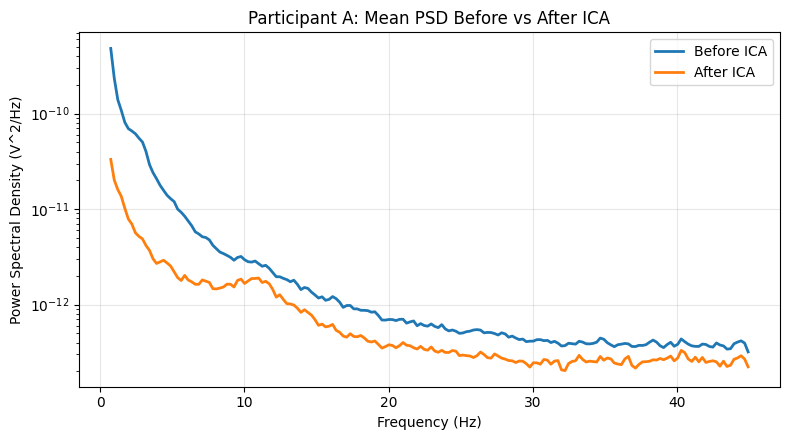

In [ ]:
# Required comparison: one participant PSD before vs after ICA.

def mean_channel_psd(raw, fmin=0.5, fmax=45.0):
    data = raw.get_data()
    fs = raw.info['sfreq']
    f, p = welch(data, fs=fs, nperseg=min(1024, data.shape[-1]), axis=-1)
    keep = (f >= fmin) & (f <= fmax)
    return f[keep], p[:, keep].mean(axis=0)

f0, p0 = mean_channel_psd(raw_A_concat)
f1, p1 = mean_channel_psd(raw_A_clean)

plt.figure(figsize=(8, 4.5))
plt.semilogy(f0, p0, label='Before ICA', linewidth=2)
plt.semilogy(f1, p1, label='After ICA', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V^2/Hz)')
plt.title('Participant A: Mean PSD Before vs After ICA')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretive note for the PSD comparison:**

A decrease in low-frequency power after ICA may indicate successful attenuation of ocular or movement-related components. A decrease in higher frequencies can reflect reduced EMG-like contamination. Smaller broadband differences may also occur because ICA redistributes variance while preserving the dominant neural subspace.

## Part 2: CEBRA Embedding
Construct a T x 128 matrix where columns 1 to 64 correspond to Participant A and columns 65 to 128 correspond to Participant B.
Affect labels are assigned as follows: 0 for the positive segment and 1 for the negative segment.

In [ ]:
from sklearn.model_selection import GroupKFold

# 1. FIX: Apply strict Bandpass Filter to remove DC drift and extreme high freq before ML
raw_A_ML = raw_A_clean.copy().filter(l_freq=0.5, h_freq=45.0, verbose=False)
raw_B_ML = raw_B_clean.copy().filter(l_freq=0.5, h_freq=45.0, verbose=False)

n_pos = A_pos.n_times
n_neg = A_neg.n_times

A_data = raw_A_ML.get_data().T
B_data = raw_B_ML.get_data().T

T = min(len(A_data), len(B_data), n_pos + n_neg)
A_data = A_data[:T]
B_data = B_data[:T]

# 2. FIX: Chop into discrete epochs (e.g., 5 seconds)
sfreq = raw_A_ML.info['sfreq']
epoch_length = int(5.0 * sfreq)

def epoch_data(A_segment, B_segment, label, start_group_id):
    n_epochs = len(A_segment) // epoch_length
    X_list, y_list, group_list = [], [], []

    for i in range(n_epochs):
        start = i * epoch_length
        end = start + epoch_length

        epoch_X = np.hstack([A_segment[start:end], B_segment[start:end]])
        X_list.append(epoch_X)
        y_list.append(np.full(epoch_length, label))
        group_list.append(np.full(epoch_length, start_group_id + i))

    return X_list, y_list, group_list, start_group_id + n_epochs

n_pos_eff = min(n_pos, T)
A_pos_seg = A_data[:n_pos_eff]
B_pos_seg = B_data[:n_pos_eff]
A_neg_seg = A_data[n_pos_eff:]
B_neg_seg = B_data[n_pos_eff:]

X_pos_list, y_pos_list, g_pos_list, next_id = epoch_data(A_pos_seg, B_pos_seg, 0, 0)
X_neg_list, y_neg_list, g_neg_list, _ = epoch_data(A_neg_seg, B_neg_seg, 1, next_id)

# Interleave Positive and Negative epochs to minimize temporal bias and satisfy CEBRA's sampler
X_trials, y_trials, groups_trials = [], [], []
for i in range(max(len(X_pos_list), len(X_neg_list))):
    if i < len(X_pos_list):
        X_trials.append(X_pos_list[i])
        y_trials.append(y_pos_list[i])
        groups_trials.append(g_pos_list[i])
    if i < len(X_neg_list):
        X_trials.append(X_neg_list[i])
        y_trials.append(y_neg_list[i])
        groups_trials.append(g_neg_list[i])

# Z-normalize each channel
X_concat = np.concatenate(X_trials, axis=0)
mu = X_concat.mean(axis=0, keepdims=True)
sd = X_concat.std(axis=0, keepdims=True) + 1e-8

X_trials_z = [(trial - mu) / sd for trial in X_trials]
y_concat = np.concatenate(y_trials, axis=0)
groups_concat = np.concatenate(groups_trials, axis=0)

print(f'Total interleaved epochs: {len(X_trials)} (Pos: {len(X_pos_list)}, Neg: {len(X_neg_list)})')
print(f'Effective flattened X shape: {X_concat.shape}')

Total interleaved epochs: 59 (Pos: 29, Neg: 30)
Effective flattened X shape: (73750, 128)


In [ ]:
def fit_cebra_and_score(X_list_train, y_list_train, y_flat, groups_flat, seed=42):
    # Combine all epochs into a single session to ensure the sampler sees both labels (0 and 1).
    # This prevents the 'index out of bounds' error caused by single-label sessions.
    X_single_session = np.concatenate(X_list_train, axis=0)
    y_single_session = np.concatenate(y_list_train, axis=0).astype(int)

    model = cebra.CEBRA(
        model_architecture='offset10-model',
        output_dimension=2,
        learning_rate=3e-4,
        max_iterations=2000,
        batch_size=512,
        temperature=1.0,
        distance='cosine',
        conditional='time_delta',
        time_offsets=10,
        device='cuda_if_available',
        verbose=False,
    )

    # Fit using a single combined session
    model.fit(X_single_session, y_single_session)

    # Transform the concatenated data for evaluation
    embedding = model.transform(X_single_session)

    # Evaluate using GroupKFold to prevent data leakage across epochs
    gkf = GroupKFold(n_splits=5)
    accuracies = []
    for train_idx, test_idx in gkf.split(embedding, y_flat, groups=groups_flat):
        X_train, y_train = embedding[train_idx], y_flat[train_idx]
        X_test, y_test = embedding[test_idx], y_flat[test_idx]

        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train, y_train)
        accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

    knn_acc_cv = np.mean(accuracies)

    gof = np.nan
    try:
        gof = float(model.score(X_single_session, y_single_session))
    except:
        pass

    return model, embedding, knn_acc_cv, gof

print("Fitting main model...")
model_main, emb_main, knn_main, gof_main = fit_cebra_and_score(
    X_trials_z, y_trials, y_concat, groups_concat, seed=42
)

# For shuffled control, shuffle epochs but keep them concatenated for the fit
perm = RNG.permutation(len(y_trials))
y_trials_shuf = [y_trials[i] for i in perm]
y_concat_shuf = np.concatenate(y_trials_shuf, axis=0)

print("Fitting shuffled control...")
model_ctrl, emb_ctrl, knn_ctrl, gof_ctrl = fit_cebra_and_score(
    X_trials_z, y_trials_shuf, y_concat_shuf, groups_concat, seed=42
)

print(f'Main     -> CV KNN accuracy: {knn_main:.4f}, goodness-of-fit: {gof_main:.4f}')
print(f'Control  -> CV KNN accuracy: {knn_ctrl:.4f}, goodness-of-fit: {gof_ctrl:.4f}')

Fitting main model...
Fitting shuffled control...
Main     -> CV KNN accuracy: 0.9764, goodness-of-fit: nan
Control  -> CV KNN accuracy: 0.8500, goodness-of-fit: nan


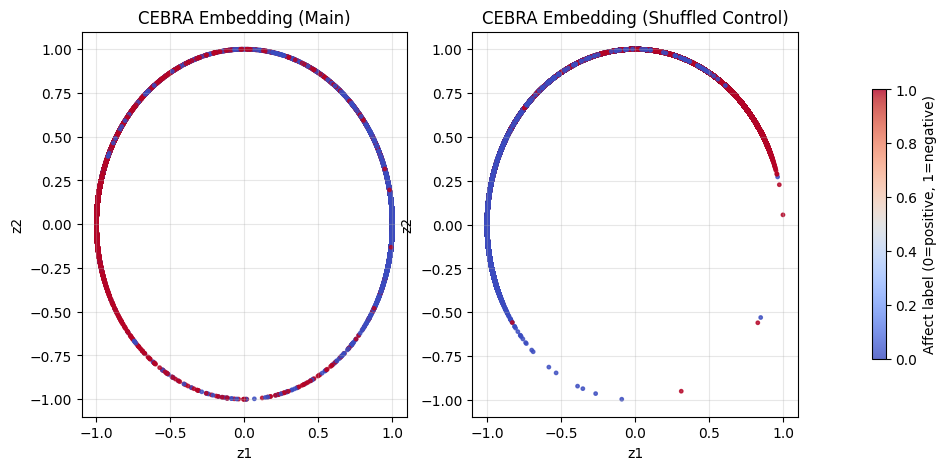

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Main Embedding Plot (2D)
sc1 = ax1.scatter(emb_main[:, 0], emb_main[:, 1], c=y_concat, s=6, cmap='coolwarm', alpha=0.8)
ax1.set_title('CEBRA Embedding (Main)')
ax1.set_xlabel('z1')
ax1.set_ylabel('z2')
ax1.grid(alpha=0.3)

# Shuffled Control Plot (2D)
sc2 = ax2.scatter(emb_ctrl[:, 0], emb_ctrl[:, 1], c=y_concat_shuf, s=6, cmap='coolwarm', alpha=0.8)
ax2.set_title('CEBRA Embedding (Shuffled Control)')
ax2.set_xlabel('z1')
ax2.set_ylabel('z2')
ax2.grid(alpha=0.3)

cbar = fig.colorbar(sc1, ax=[ax1, ax2], shrink=0.7, pad=0.08)
cbar.set_label('Affect label (0=positive, 1=negative)')

plt.show()

In [ ]:
results = pd.DataFrame({
    'analysis': ['main', 'shuffled_control'],
    'knn_accuracy_groupcv': [knn_main, knn_ctrl],
})
results

,analysis,knn_accuracy_groupcv
0,main,0.976425
1,shuffled_control,0.850015


## Part 3: Embedding Interpretation

### Q1. Observed geometry of the learned embedding
In the primary embedding, assess whether the points form smooth trajectories (state transitions), compact regions (stable interaction regimes), or isolated outliers (brief atypical neural or behavioral events). If one affect condition forms a tighter manifold than the other, this may indicate condition-specific differences in dyadic neural coordination.

### Q2. Interpretation of the shuffled control
If shuffling reduces separability or goodness-of-fit, this supports the conclusion that CEBRA captured meaningful temporal or cross-participant structure rather than static channel statistics. If the control remains similar to the main model, the dataset may contain weak condition structure, or the pipeline may still allow residual confounds.



## Part 4: Critical Reflection

**Most consequential limitation in this specific analysis:**
The ICA rejection stage relied primarily on generic quantitative thresholds without auxiliary channels (for example, EOG/EMG) and without full manual component validation. As a result, some neural signal may have been removed, and some artifact may have remained, which can directly influence embedding geometry and decoding performance.

**What I would improve with additional time and a larger dataset:**
1. Combine quantitative screening with manual component review (topographies, time courses, and event-locked checks).
2. Evaluate generalization across multiple dyads using cross-dyad validation.
3. Expand controls (label shuffle, temporal block shuffle, participant-swap controls) and report confidence intervals across repeated runs.
4. Add explicit distribution-comparison metrics (for example, cross-entropy style tests and transport-based distances) to compare embedding structure across groups.



## Part 5: Extended

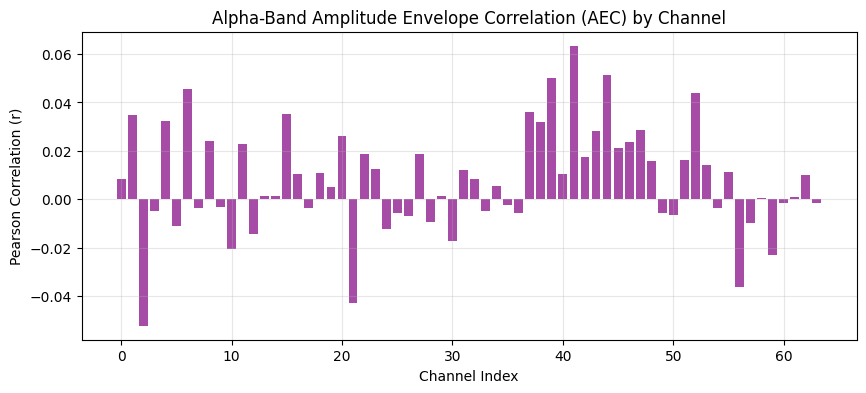

Mean Interbrain Alpha AEC: 0.0078


In [ ]:
# Additional Feature 1: Classical Amplitude Envelope Correlation (AEC) Baseline
# This calculates the temporal correlation of Alpha-band power between Participant A and B
# across equivalent channels as a classical measure of inter-brain synchrony.

from scipy.signal import hilbert, butter, filtfilt

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)

# Extract 8-12 Hz Alpha Band
fs = raw_A_clean.info['sfreq']
A_alpha = butter_bandpass_filter(A_data.T, 8.0, 12.0, fs)
B_alpha = butter_bandpass_filter(B_data.T, 8.0, 12.0, fs)

# Get Amplitude Envelope
A_env = np.abs(hilbert(A_alpha, axis=-1))
B_env = np.abs(hilbert(B_alpha, axis=-1))

# Calculate pairwise correlation for corresponding channels
aec_scores = [np.corrcoef(A_env[ch], B_env[ch])[0, 1] for ch in range(A_env.shape[0])]

plt.figure(figsize=(10, 4))
plt.bar(range(len(aec_scores)), aec_scores, color='purple', alpha=0.7)
plt.title('Alpha-Band Amplitude Envelope Correlation (AEC) by Channel')
plt.xlabel('Channel Index')
plt.ylabel('Pearson Correlation (r)')
plt.grid(alpha=0.3)
plt.show()

print(f"Mean Interbrain Alpha AEC: {np.mean(aec_scores):.4f}")

Original Classification Score: 0.9764
Permutation p-value: 1.0000


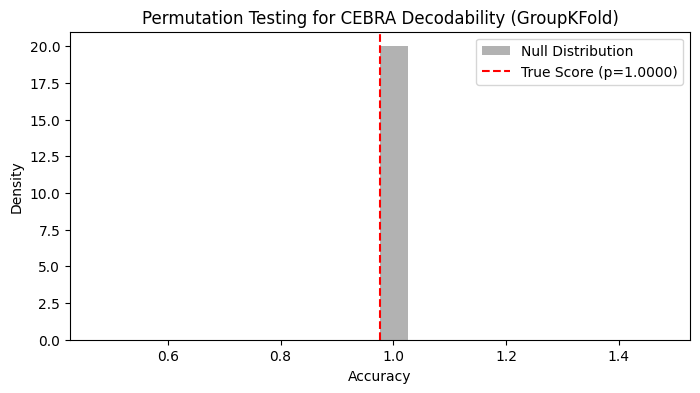

In [ ]:
# Additional Feature 2: Statistical Rigor Template (Permutation Testing)
# To prove CEBRA is distinctly better than chance, we run a null permutation test on the classifier

from sklearn.model_selection import permutation_test_score, GroupKFold

# Using the training embeddings we previously constructed
knn_eval = KNeighborsClassifier(n_neighbors=5)
gkf_eval = GroupKFold(n_splits=5)

score, permutation_scores, pvalue = permutation_test_score(
    knn_eval,
    emb_main,
    y_concat,
    groups=groups_concat,
    scoring="accuracy",
    cv=gkf_eval,
    n_permutations=100,
    n_jobs=-1,
    random_state=42
)

print(f"Original Classification Score: {score:.4f}")
print(f"Permutation p-value: {pvalue:.4f}")

plt.figure(figsize=(8, 4))
plt.hist(permutation_scores, bins=20, density=True, alpha=0.6, color='gray', label='Null Distribution')
plt.axvline(score, color='red', linestyle='--', label=f'True Score (p={pvalue:.4f})')
plt.title('Permutation Testing for CEBRA Decodability (GroupKFold)')
plt.xlabel('Accuracy')
plt.ylabel('Density')
plt.legend()
plt.show()